### Putting them together 

 Connecting everything learned from course one

In [3]:
# Import PyTorch and matplotlib

import torch
from torch import nn 
import matplotlib.pyplot as plt

### Setting Device Agnostic Code

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device}")

 Using device: cpu


### Getting the Data 


In [5]:
# Creating Known data 
weight = 0.7
bias = 0.3

# Generate values using arange 
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias


### Data Splitting

Data would be splitted as Train_data and Test_data in the ratio 80:20

In [6]:
train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### Data Visualization

In [7]:
def plot_prediction(train_data=X_train,
                    train_label=y_train,
                    test_data=X_test,
                    test_label=y_test,
                    predictions=None):
    
    plt.figure(figsize = (8, 6))
    plt.scatter(train_data, train_label, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_label, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="prediction")

    plt.legend(prop={"size":14});

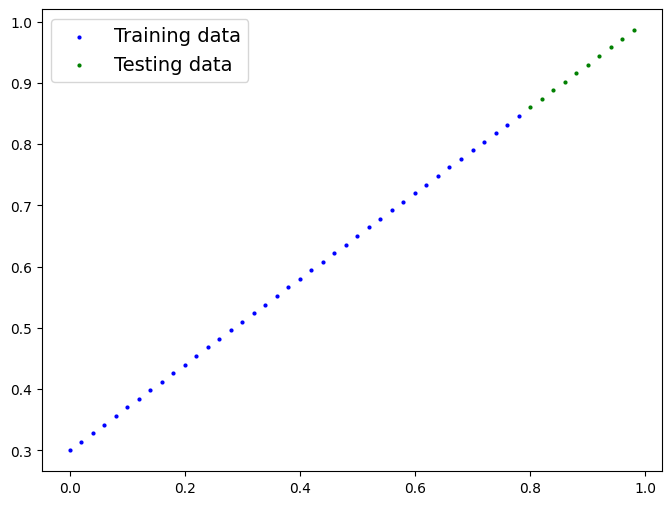

In [8]:
plot_prediction()

### Build Model 

In [ ]:
from torch import nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(). __init__()
        self.weight = nn.Parameter(torch.randn(1,
                                               requires_grad = True,
                                               dtype = torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad = True,
                                             dtype = torch.float))
    def forward(self, x: torch.Tensor)-> torch.Tensor:
        return self.weight * x + self.bias

### Building Model 2

The linear model Model is achieved by subclassing nn.Module

In [ ]:
class LinearRegressionModel2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters. Also called Linear Transform or fully connected layer
        self.linear_layer = nn.Linear(in_features=1,
                                      out_features=1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

    # 
 

### Cross-checking PyTorch content

In [11]:
torch.manual_seed(42)

# Creating an instance of the code 
model_1 = LinearRegressionModel() 
#model_1 = LinearRegressionModel2()

model_1.state_dict() 


OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making Predictions

In [12]:
with torch.inference_mode():
    y_predict = model_1(X_test)

y_predict

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

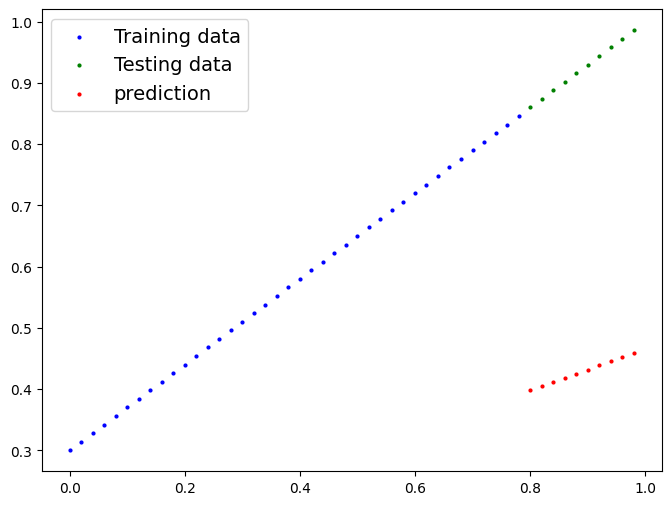

In [13]:
plot_prediction(predictions=y_predict)

### Training the Model 

In [14]:
# Setup loss function
loss_func = nn.L1Loss()

# Setup optimizer function
optimiser = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.01)

In [22]:
epochs = 200

# Tracking the Values
epoch_count = []
loss_count = []
test_loss_value = []

# Device Agnostic code for data
X_train = X_train.to(device)
y_train =y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    y_predict = model_1(X_train)
    loss = loss_func(y_predict, y_train)
    optimiser.zero_grad()   # removes gradient tracking
    loss.backward()
    optimiser.step() 

    model_1.eval() # Preparation to train 
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_func(test_pred, y_test)

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            loss_count.append(loss)
            test_loss_value.append(test_loss)
            print(f"Epoch: {epoch} | Loss : {loss} | Test loss: {test_loss}")

            print(model_1.state_dict()) # Print out Model State_dict

Epoch: 0 | Loss : 0.008932482451200485 | Test loss: 0.005023092031478882
OrderedDict({'weight': tensor([0.6951]), 'bias': tensor([0.2993])})
Epoch: 10 | Loss : 0.008932482451200485 | Test loss: 0.005023092031478882
OrderedDict({'weight': tensor([0.6951]), 'bias': tensor([0.2993])})
Epoch: 20 | Loss : 0.008932482451200485 | Test loss: 0.005023092031478882
OrderedDict({'weight': tensor([0.6951]), 'bias': tensor([0.2993])})
Epoch: 30 | Loss : 0.008932482451200485 | Test loss: 0.005023092031478882
OrderedDict({'weight': tensor([0.6951]), 'bias': tensor([0.2993])})
Epoch: 40 | Loss : 0.008932482451200485 | Test loss: 0.005023092031478882
OrderedDict({'weight': tensor([0.6951]), 'bias': tensor([0.2993])})
Epoch: 50 | Loss : 0.008932482451200485 | Test loss: 0.005023092031478882
OrderedDict({'weight': tensor([0.6951]), 'bias': tensor([0.2993])})
Epoch: 60 | Loss : 0.008932482451200485 | Test loss: 0.005023092031478882
OrderedDict({'weight': tensor([0.6951]), 'bias': tensor([0.2993])})
Epoch: 

My lesson from this, is, even the boring can be fun ....

### Visualising performance

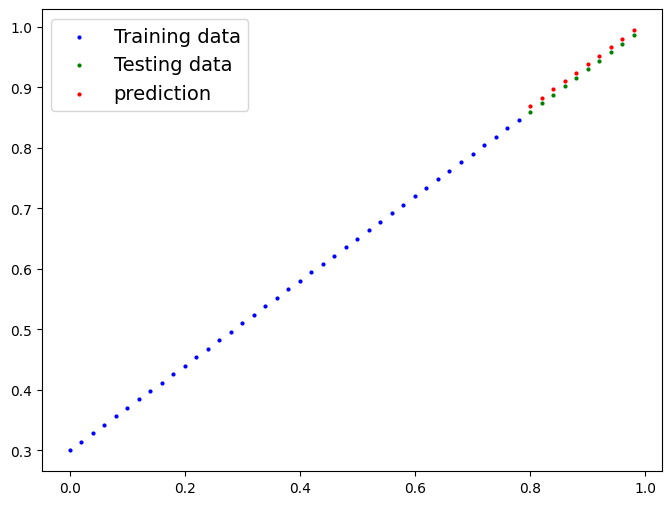

In [42]:
plot_prediction(predictions = test_pred)

### Done!!!!!!!!

Last chechout time -> 8:3207

In [25]:
model_1.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

### Saving and loading a Trained model 

In [33]:
from pathlib import Path

# model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# model save path
MODEL_NAME = "second_model_pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME

# Saving the model
torch.save(obj= model_1.state_dict(),
           f = MODEL_SAVE_PATH)
print(f"Saved model to: {MODEL_SAVE_PATH}")


Saved model to: models/second_model_pytorch_workflow.pth


### Loading the model

In [27]:
model_1.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [30]:
loaded_model_2 = LinearRegressionModel()

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [34]:
loaded_model_2.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

### Evaluating Loaded Model

In [40]:
test_pred

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [43]:
loaded_model_2.eval()
with torch.inference_mode():
    loaded_model_2_preds = loaded_model_2(X_test)
test_pred == loaded_model_2_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])